In [ ]:
import pandas as pd

# load dataset
df = pd.read_csv("Jamboree_Admission.csv")


In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
# basic checks
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nInfo:")
print(df.info())

Shape: (500, 9)

First 5 rows:
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL 

500 rows, 9 columns

No missing values

Target = Chance of Admit

Serial No. → useless for model

#Data Cleaning

In [ ]:
# drop serial number
df = df.drop(columns=["Serial No."])

# check duplicates
print("Duplicate rows:", df.duplicated().sum())

# statistical summary
print("\nSummary:")
print(df.describe())

Duplicate rows: 0

Summary:
        GRE Score  TOEFL Score  University Rating         SOP       LOR   \
count  500.000000   500.000000         500.000000  500.000000  500.00000   
mean   316.472000   107.192000           3.114000    3.374000    3.48400   
std     11.295148     6.081868           1.143512    0.991004    0.92545   
min    290.000000    92.000000           1.000000    1.000000    1.00000   
25%    308.000000   103.000000           2.000000    2.500000    3.00000   
50%    317.000000   107.000000           3.000000    3.500000    3.50000   
75%    325.000000   112.000000           4.000000    4.000000    4.00000   
max    340.000000   120.000000           5.000000    5.000000    5.00000   

             CGPA    Research  Chance of Admit   
count  500.000000  500.000000         500.00000  
mean     8.576440    0.560000           0.72174  
std      0.604813    0.496884           0.14114  
min      6.800000    0.000000           0.34000  
25%      8.127500    0.000000        

No duplicates,
No missing values,
Values look reasonable (no obvious invalid ranges)

#EDA

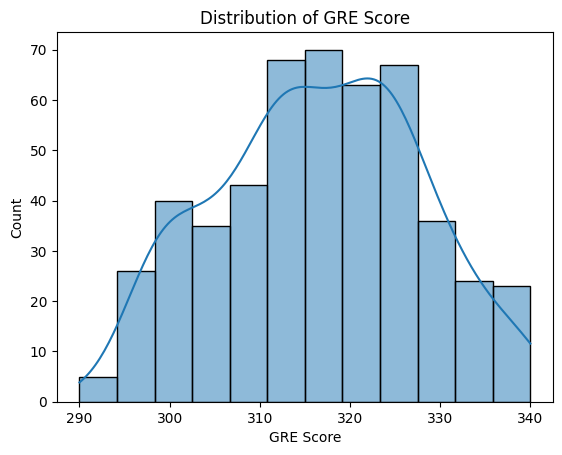

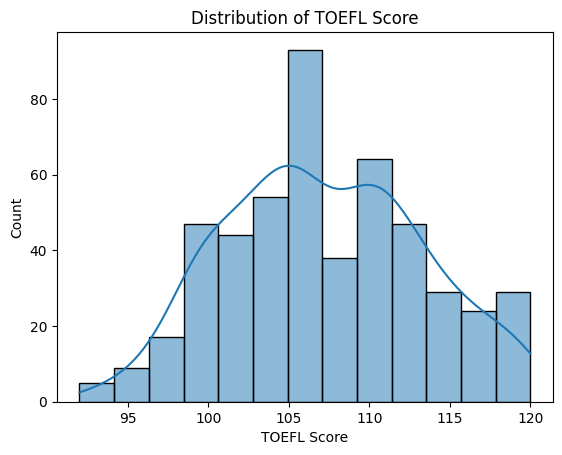

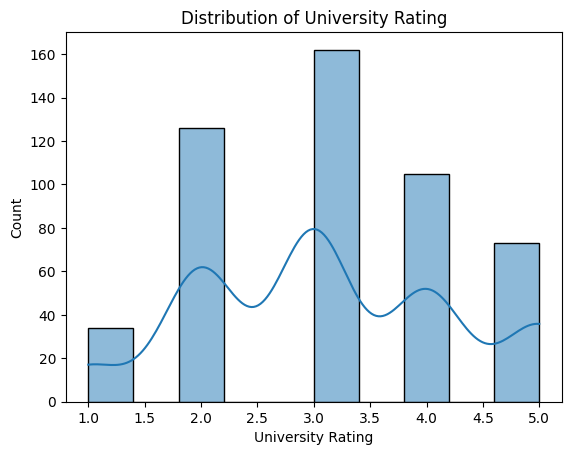

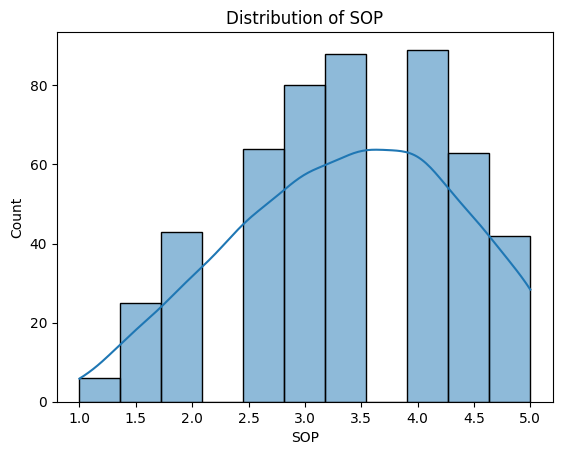

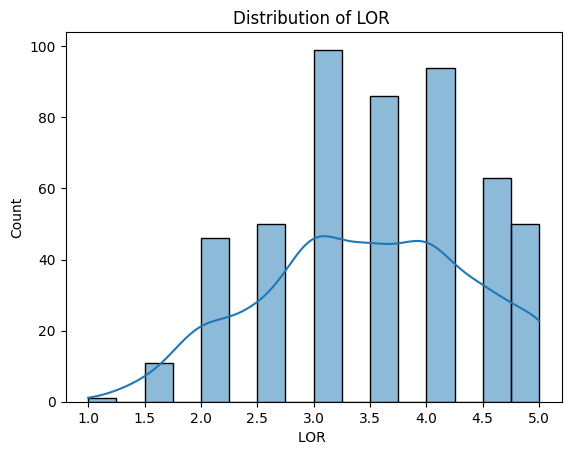

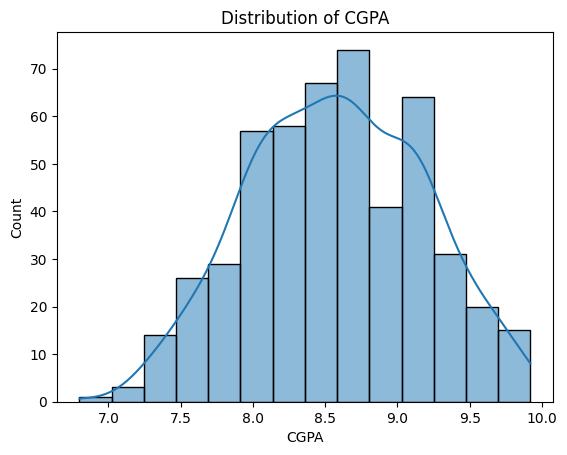

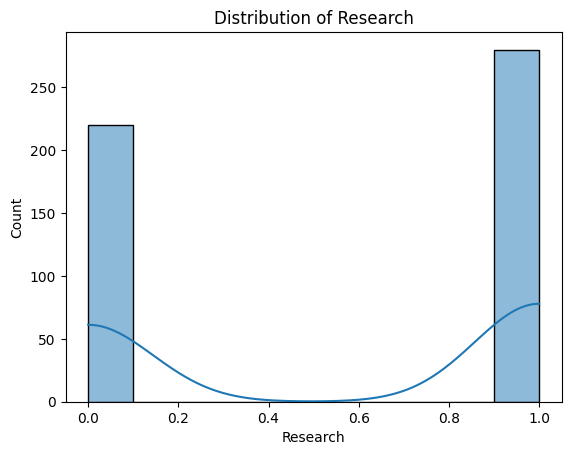

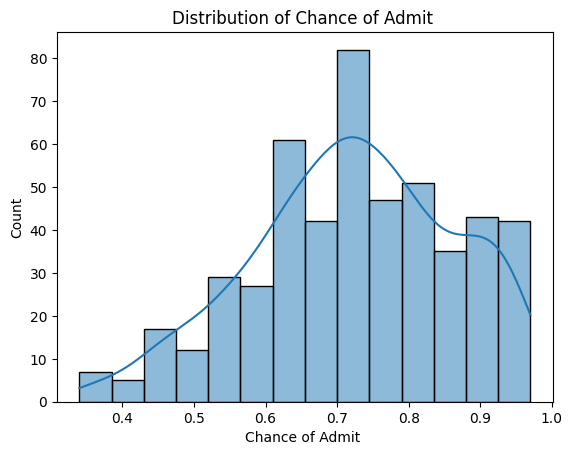

In [ ]:
#Univariate Analysis
import matplotlib.pyplot as plt
import seaborn as sns

# numerical columns
num_cols = df.columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Normal / Near-Normal Distribution

* GRE Score is approximately normally distributed.
* TOEFL Score is close to normal with slight variation.
* CGPA follows a near-normal distribution.

Slightly Skewed Variables

* SOP shows slight right skewness.
* LOR also shows slight right skewness.
* Chance of Admit is mildly right-skewed.

Discrete Variables

* University Rating behaves like a categorical variable with distinct levels.
* Research is a binary variable (0 and 1) with slight imbalance.

Overall Data Quality

* No significant outliers are observed.
* The overall distribution of variables appears reasonable and suitable for modeling.

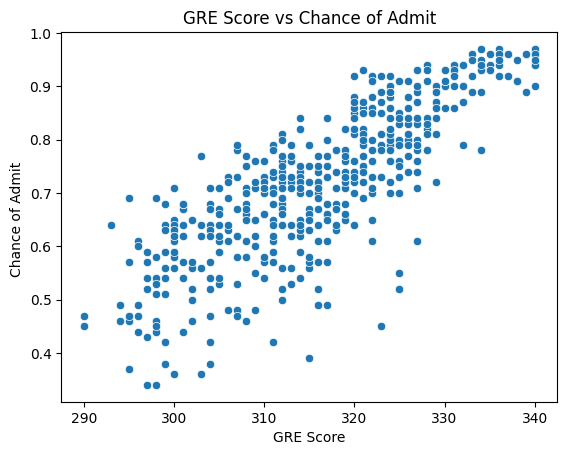

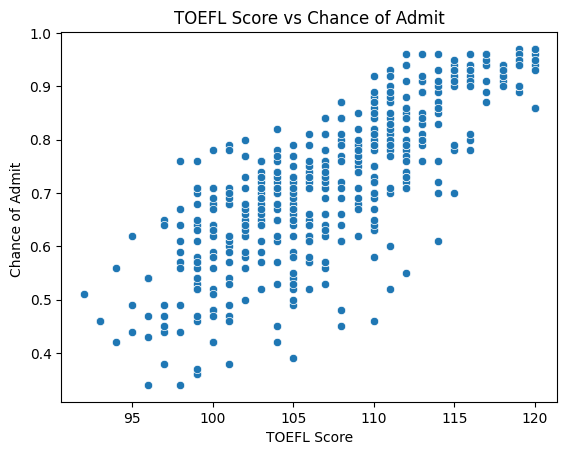

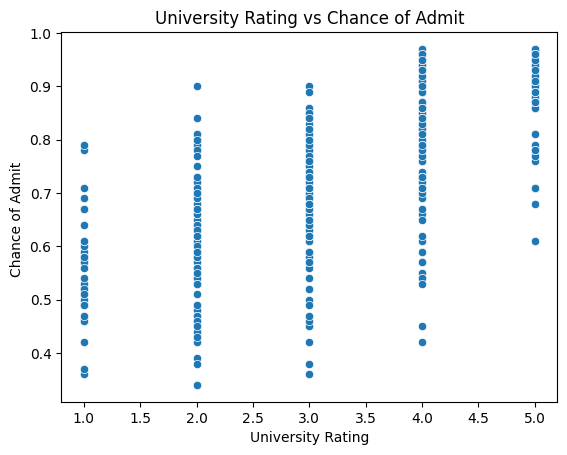

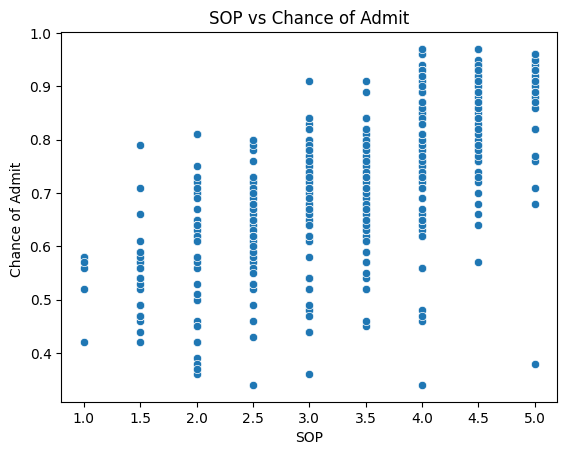

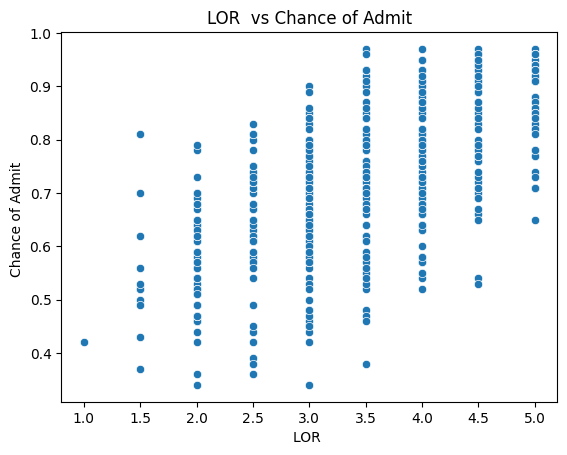

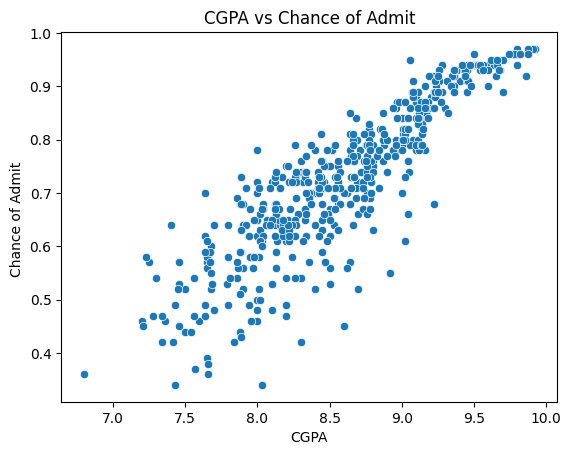

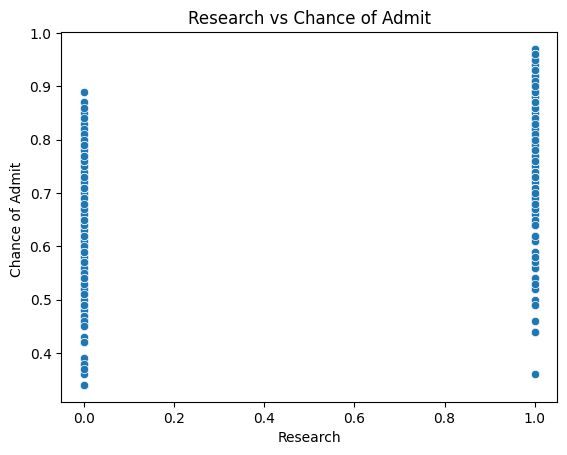

In [ ]:
#Bivariate Analysis
# scatter plots vs target
target = "Chance of Admit "

for col in df.columns:
    if col != target:
        plt.figure()
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs Chance of Admit")
        plt.show()

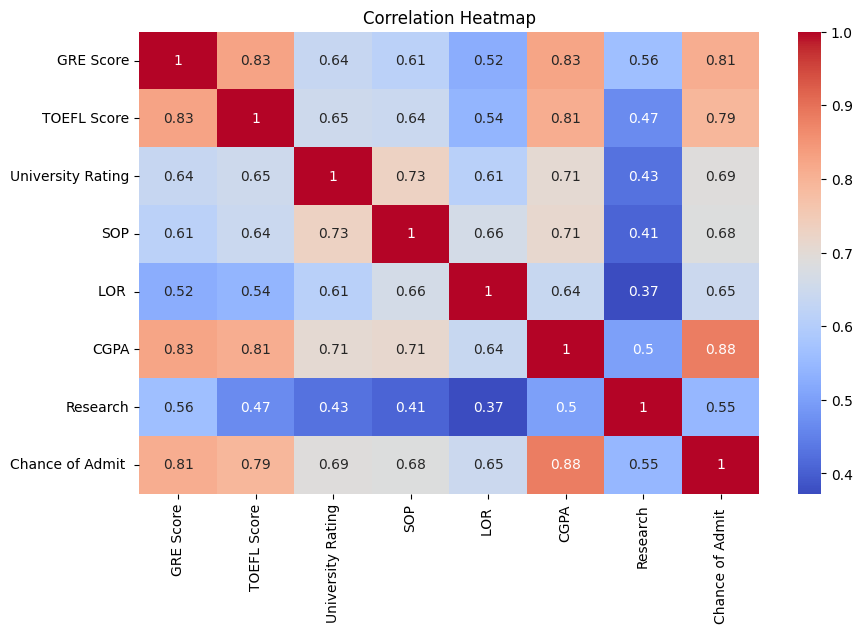

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Strong correlation with target:
* CGPA has the strongest positive correlation (~0.88)
* GRE Score shows strong positive correlation (~0.81)
* TOEFL Score also has strong positive correlation (~0.79)

Moderate correlation:
* University Rating (~0.69)
* SOP (~0.68)
* LOR (~0.65)

Weak to moderate:
* Research (~0.55)
* Scatter plot insights:
* Clear linear trend for CGPA, GRE, TOEFL
* Higher values → higher chance of admission
* Research shows higher probability when = 1
* SOP, LOR, University Rating show step-wise upward trend

Multicollinearity:
* GRE and TOEFL are highly correlated (~0.83)
* GRE and CGPA also high (~0.83)
* TOEFL and CGPA also high (~0.81)

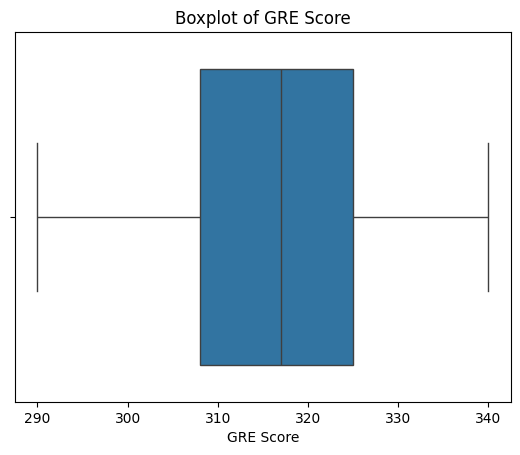

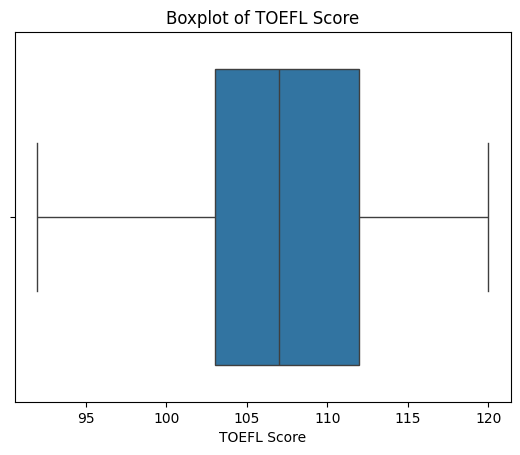

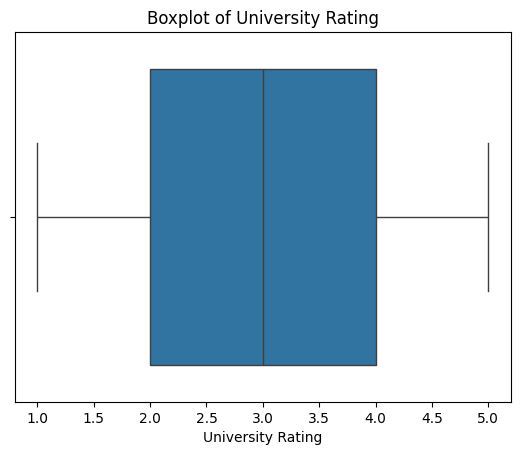

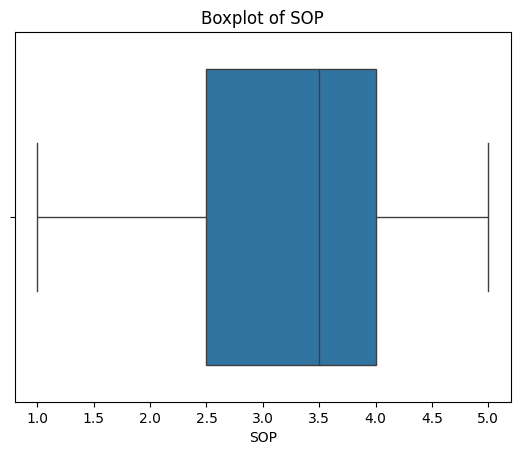

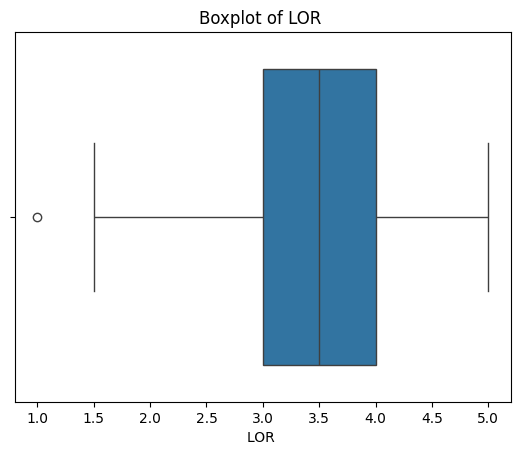

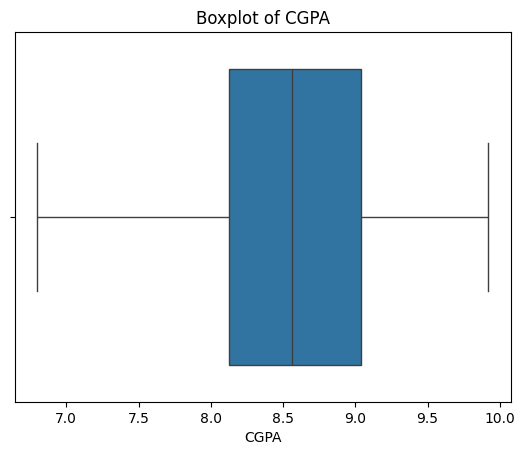

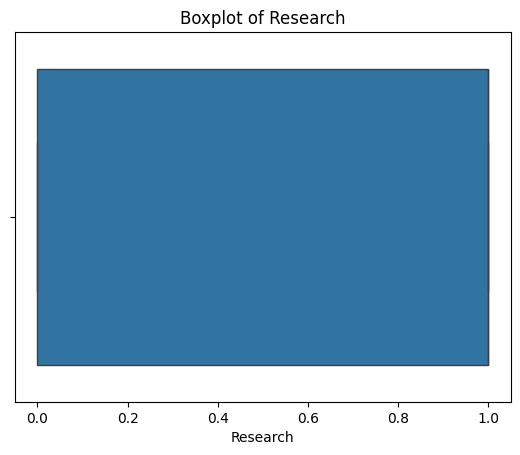

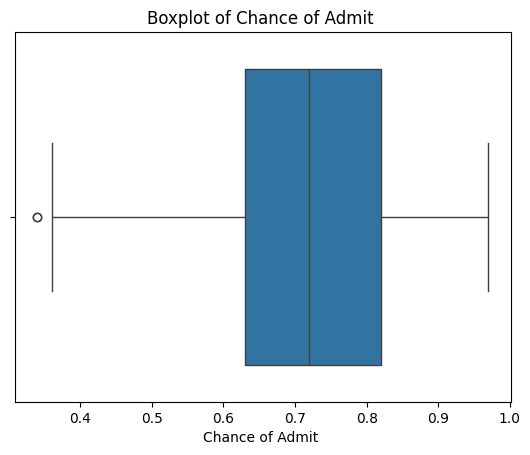

In [ ]:
#Outlier Detection
for col in df.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Outlier Analysis

GRE Score does not show any significant outliers.

TOEFL Score does not show any significant outliers.

University Rating has no outliers as it is a discrete variable.

SOP does not show any major outliers.

LOR shows a minor outlier at the lower end.

CGPA does not show any significant outliers.

Research is a binary variable, so outlier analysis is not applicable.

Chance of Admit shows a minor outlier at the lower end.

Conclusion on Outliers

Outliers are minimal and not severe.
No outlier treatment is required as they do not significantly affect the dataset.

#Linear Regression (Statsmodels)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# define X and y
X = df.drop("Chance of Admit ", axis=1)
y = df["Chance of Admit "]

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)

model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Tue, 05 May 2026   Prob (F-statistic):          3.41e-142
Time:                        05:27:25   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7242      0.003    241.441      0.0

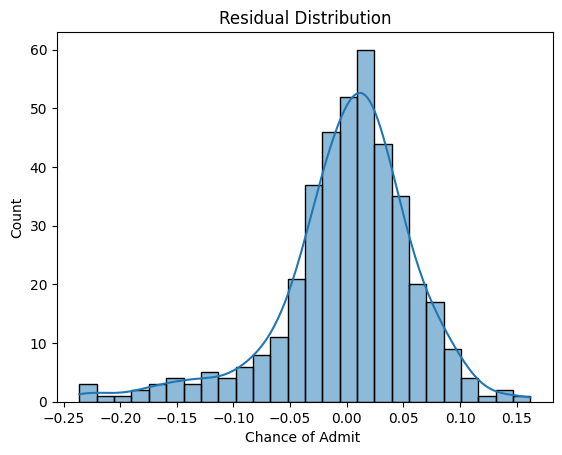

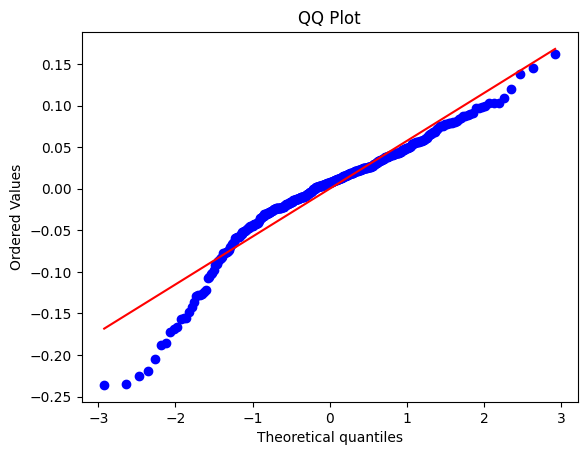

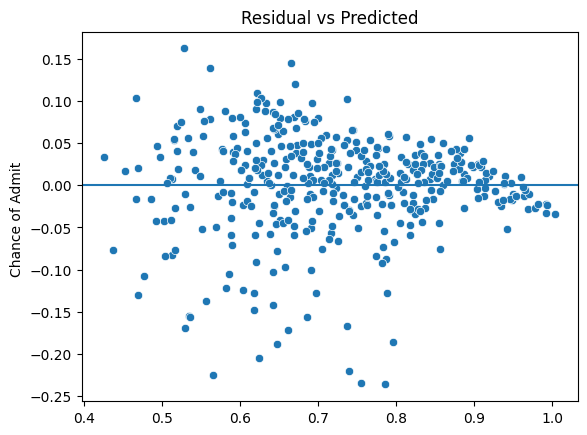

Mean of residuals: -4.056477376224166e-16


In [ ]:
#Residual Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# predictions
y_pred = model.predict(X_train_sm)

# residuals
residuals = y_train - y_pred

# 1. Histogram
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# 2. QQ plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

# 3. Residual vs Predicted
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0)
plt.title("Residual vs Predicted")
plt.show()

# 4. Mean of residuals
print("Mean of residuals:", residuals.mean())

In [ ]:
#residuals mean
print(residuals.mean())

-4.056477376224166e-16


In [ ]:
#multicollinearity using VIF.

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled, i) for i in range(X_train_scaled.shape[1])]

print(vif_data)

             feature       VIF
0          GRE Score  4.489983
1        TOEFL Score  3.664298
2  University Rating  2.572110
3                SOP  2.785764
4               LOR   1.977698
5               CGPA  4.654540
6           Research  1.518065


#Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# predictions
y_train_pred = model.predict(X_train_sm)
X_test_sm = sm.add_constant(X_test_scaled)
y_test_pred = model.predict(X_test_sm)

# metrics
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Train MAE: 0.042533340611643065
Test MAE: 0.042722654277053636
Train RMSE: 0.05938480848210052
Test RMSE: 0.06086588041578315
Train R2: 0.8210671369321554
Test R2: 0.8188432567829627


#Ridge & Lasso Regression

In [ ]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

# Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_train, train_pred, y_test, test_pred):
    print(f"\n{name} Performance:")
    print("Train MAE:", mean_absolute_error(y_train, train_pred))
    print("Test MAE:", mean_absolute_error(y_test, test_pred))
    print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
    print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
    print("Train R2:", r2_score(y_train, train_pred))
    print("Test R2:", r2_score(y_test, test_pred))

# evaluate
evaluate_model("Ridge", y_train, ridge_train_pred, y_test, ridge_test_pred)
evaluate_model("Lasso", y_train, lasso_train_pred, y_test, lasso_test_pred)


Ridge Performance:
Train MAE: 0.042529184932157786
Test MAE: 0.04274719474628152
Train RMSE: 0.059385471340338336
Test RMSE: 0.06087507177653933
Train R2: 0.8210631423824621
Test R2: 0.8187885396675396

Lasso Performance:
Train MAE: 0.04365375627785551
Test MAE: 0.04270927740179335
Train RMSE: 0.060761668605976496
Test RMSE: 0.06167490656830304
Train R2: 0.8126736918363732
Test R2: 0.8139953985227918


#Map Coefficients to Feature Names

In [ ]:
import pandas as pd

coeff_df = pd.DataFrame({
    "Feature": ["Intercept"] + list(X.columns),
    "Coefficient": model.params
})

print(coeff_df)

                 Feature  Coefficient
const          Intercept     0.724175
x1             GRE Score     0.026671
x2           TOEFL Score     0.018226
x3     University Rating     0.002940
x4                   SOP     0.001788
x5                  LOR      0.015866
x6                  CGPA     0.067581
x7              Research     0.011940
